<a href="https://colab.research.google.com/github/Lucianadeoliveira/gaTE-lab/blob/main/FRALCAT/MultiFastaAlphaFold2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ColabFold with Multi-FASTA Support

This notebook is a customized version of **ColabFold** developed at the **GaTe Lab - University of São Paulo (USP)** as part of the **FRALCAT** project. It extends the original ColabFold pipeline to support input from **Multi-FASTA files** containing **amino acid sequences**.

### ⚠️ Important Notes:
- To use the notebook with full functionality, you **must authorize Google Drive** access. This is necessary to save inputs, outputs, and intermediate files.
- The notebook is divided into two main parts:
  1. **Original ColabFold**: Designed to run structure prediction for a single protein sequence.
  2. **Modified ColabFold (Multi-FASTA mode)**: Adapted to process multiple sequences automatically from a single file.

### Before You Start:
To ensure that all dependencies are properly installed, **you must first run the original ColabFold section with a single sequence**. You can use one of your sequences for this step and optionally rename the job.  
Once the initial setup is complete, you can move on to the Multi-FASTA section to batch-process multiple sequences.

---

This documentation aims to guide users smoothly through both standard and extended functionalities. Please follow the steps in order for the best results.


## Authorize Google Drive

To enable saving and loading files (e.g., input sequences, results, models), you need to **authorize access to your Google Drive**.

Click the link that appears below after running the code cell. Sign in with your Google account and copy the authorization code into the provided field. Your Drive will then be accessible under `/content/drive`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## ColabFold: Single-Sequence Mode

This section runs the **original ColabFold pipeline** for a single amino acid sequence.

 **You must run this section first** to ensure that all required dependencies are installed.  
An example sequence is provided for testing, but you can also paste your own sequence and optionally rename the job.

This setup step is necessary even if you plan to use the Multi-FASTA mode later.

**All ColabFold details are provided below**, including input configuration and output interpretation.


<img src="https://raw.githubusercontent.com/sokrypton/ColabFold/main/.github/ColabFold_Marv_Logo_Small.png" height="200" align="right" style="height:240px">

##ColabFold v1.5.5: AlphaFold2 using MMseqs2

Easy to use protein structure and complex prediction using [AlphaFold2](https://www.nature.com/articles/s41586-021-03819-2) and [Alphafold2-multimer](https://www.biorxiv.org/content/10.1101/2021.10.04.463034v1). Sequence alignments/templates are generated through [MMseqs2](mmseqs.com) and [HHsearch](https://github.com/soedinglab/hh-suite). For more details, see <a href="#Instructions">bottom</a> of the notebook, checkout the [ColabFold GitHub](https://github.com/sokrypton/ColabFold) and read our manuscript.
Old versions: [v1.4](https://colab.research.google.com/github/sokrypton/ColabFold/blob/v1.4.0/AlphaFold2.ipynb), [v1.5.1](https://colab.research.google.com/github/sokrypton/ColabFold/blob/v1.5.1/AlphaFold2.ipynb), [v1.5.2](https://colab.research.google.com/github/sokrypton/ColabFold/blob/v1.5.2/AlphaFold2.ipynb), [v1.5.3-patch](https://colab.research.google.com/github/sokrypton/ColabFold/blob/56c72044c7d51a311ca99b953a71e552fdc042e1/AlphaFold2.ipynb)

[Mirdita M, Schütze K, Moriwaki Y, Heo L, Ovchinnikov S, Steinegger M. ColabFold: Making protein folding accessible to all.
*Nature Methods*, 2022](https://www.nature.com/articles/s41592-022-01488-1)

In [ ]:
#@title Input protein sequence(s), then hit `Runtime` -> `Run all`
from google.colab import files
import os
import re
import hashlib
import random

from sys import version_info
python_version = f"{version_info.major}.{version_info.minor}"

def add_hash(x,y):
  return x+"_"+hashlib.sha1(y.encode()).hexdigest()[:5]

query_sequence = 'PIAQIHILEGRSDEQKETLIREVSEAISRSLDAPLTSVRVIITEMAKGHFGIGGELASK' #@param {type:"string"}
#@markdown  - Use `:` to specify inter-protein chainbreaks for **modeling complexes** (supports homo- and hetro-oligomers). For example **PI...SK:PI...SK** for a homodimer
jobname = 'test' #@param {type:"string"}
# number of models to use
num_relax = 0 #@param [0, 1, 5] {type:"raw"}
#@markdown - specify how many of the top ranked structures to relax using amber
template_mode = "none" #@param ["none", "pdb100","custom"]
#@markdown - `none` = no template information is used. `pdb100` = detect templates in pdb100 (see [notes](#pdb100)). `custom` - upload and search own templates (PDB or mmCIF format, see [notes](#custom_templates))

use_amber = num_relax > 0

# remove whitespaces
query_sequence = "".join(query_sequence.split())

basejobname = "".join(jobname.split())
basejobname = re.sub(r'\W+', '', basejobname)
jobname = add_hash(basejobname, query_sequence)

# check if directory with jobname exists
def check(folder):
  if os.path.exists(folder):
    return False
  else:
    return True
if not check(jobname):
  n = 0
  while not check(f"{jobname}_{n}"): n += 1
  jobname = f"{jobname}_{n}"

# make directory to save results
os.makedirs(jobname, exist_ok=True)

# save queries
queries_path = os.path.join(jobname, f"{jobname}.csv")
with open(queries_path, "w") as text_file:
  text_file.write(f"id,sequence\n{jobname},{query_sequence}")

if template_mode == "pdb100":
  use_templates = True
  custom_template_path = None
elif template_mode == "custom":
  custom_template_path = os.path.join(jobname,f"template")
  os.makedirs(custom_template_path, exist_ok=True)
  uploaded = files.upload()
  use_templates = True
  for fn in uploaded.keys():
    os.rename(fn,os.path.join(custom_template_path,fn))
else:
  custom_template_path = None
  use_templates = False

print("jobname",jobname)
print("sequence",query_sequence)
print("length",len(query_sequence.replace(":","")))



jobname test_a5e17
sequence PIAQIHILEGRSDEQKETLIREVSEAISRSLDAPLTSVRVIITEMAKGHFGIGGELASK
length 59


In [ ]:
#@title Install dependencies
%%time
import os
USE_AMBER = use_amber
USE_TEMPLATES = use_templates
PYTHON_VERSION = python_version

if not os.path.isfile("COLABFOLD_READY"):
  print("installing colabfold...")
  os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
  if os.environ.get('TPU_NAME', False) != False:
    os.system("pip uninstall -y jax jaxlib")
    os.system("pip install --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
  os.system("touch COLABFOLD_READY")

if USE_AMBER or USE_TEMPLATES:
  if not os.path.isfile("CONDA_READY"):
    print("installing conda...")
    os.system("wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Mambaforge-Linux-x86_64.sh")
    os.system("bash Mambaforge-Linux-x86_64.sh -bfp /usr/local")
    os.system("mamba config --set auto_update_conda false")
    os.system("touch CONDA_READY")

if USE_TEMPLATES and not os.path.isfile("HH_READY") and USE_AMBER and not os.path.isfile("AMBER_READY"):
  print("installing hhsuite and amber...")
  os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 openmm=7.7.0 python='{PYTHON_VERSION}' pdbfixer")
  os.system("touch HH_READY")
  os.system("touch AMBER_READY")
else:
  if USE_TEMPLATES and not os.path.isfile("HH_READY"):
    print("installing hhsuite...")
    os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 python='{PYTHON_VERSION}'")
    os.system("touch HH_READY")
  if USE_AMBER and not os.path.isfile("AMBER_READY"):
    print("installing amber...")
    os.system(f"mamba install -y -c conda-forge openmm=7.7.0 python='{PYTHON_VERSION}' pdbfixer")
    os.system("touch AMBER_READY")

installing colabfold...
CPU times: user 126 ms, sys: 29.2 ms, total: 155 ms
Wall time: 44.4 s


In [ ]:
#@markdown ### MSA options (custom MSA upload, single sequence, pairing mode)
msa_mode = "mmseqs2_uniref_env" #@param ["mmseqs2_uniref_env", "mmseqs2_uniref","single_sequence","custom"]
pair_mode = "unpaired_paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
#@markdown - "unpaired_paired" = pair sequences from same species + unpaired MSA, "unpaired" = seperate MSA for each chain, "paired" - only use paired sequences.

# decide which a3m to use
if "mmseqs2" in msa_mode:
  a3m_file = os.path.join(jobname,f"{jobname}.a3m")

elif msa_mode == "custom":
  a3m_file = os.path.join(jobname,f"{jobname}.custom.a3m")
  if not os.path.isfile(a3m_file):
    custom_msa_dict = files.upload()
    custom_msa = list(custom_msa_dict.keys())[0]
    header = 0
    import fileinput
    for line in fileinput.FileInput(custom_msa,inplace=1):
      if line.startswith(">"):
         header = header + 1
      if not line.rstrip():
        continue
      if line.startswith(">") == False and header == 1:
         query_sequence = line.rstrip()
      print(line, end='')

    os.rename(custom_msa, a3m_file)
    queries_path=a3m_file
    print(f"moving {custom_msa} to {a3m_file}")

else:
  a3m_file = os.path.join(jobname,f"{jobname}.single_sequence.a3m")
  with open(a3m_file, "w") as text_file:
    text_file.write(">1\n%s" % query_sequence)

In [ ]:
#@markdown ### Advanced settings
model_type = "auto" #@param ["auto", "alphafold2_ptm", "alphafold2_multimer_v1", "alphafold2_multimer_v2", "alphafold2_multimer_v3", "deepfold_v1"]
#@markdown - if `auto` selected, will use `alphafold2_ptm` for monomer prediction and `alphafold2_multimer_v3` for complex prediction.
#@markdown Any of the mode_types can be used (regardless if input is monomer or complex).
num_recycles = "3" #@param ["auto", "0", "1", "3", "6", "12", "24", "48"]
#@markdown - if `auto` selected, will use `num_recycles=20` if `model_type=alphafold2_multimer_v3`, else `num_recycles=3` .
recycle_early_stop_tolerance = "auto" #@param ["auto", "0.0", "0.5", "1.0"]
#@markdown - if `auto` selected, will use `tol=0.5` if `model_type=alphafold2_multimer_v3` else `tol=0.0`.
relax_max_iterations = 200 #@param [0, 200, 2000] {type:"raw"}
#@markdown - max amber relax iterations, `0` = unlimited (AlphaFold2 default, can take very long)
pairing_strategy = "greedy" #@param ["greedy", "complete"] {type:"string"}
#@markdown - `greedy` = pair any taxonomically matching subsets, `complete` = all sequences have to match in one line.


#@markdown #### Sample settings
#@markdown -  enable dropouts and increase number of seeds to sample predictions from uncertainty of the model.
#@markdown -  decrease `max_msa` to increase uncertainity
max_msa = "auto" #@param ["auto", "512:1024", "256:512", "64:128", "32:64", "16:32"]
num_seeds = 1 #@param [1,2,4,8,16] {type:"raw"}
use_dropout = False #@param {type:"boolean"}

num_recycles = None if num_recycles == "auto" else int(num_recycles)
recycle_early_stop_tolerance = None if recycle_early_stop_tolerance == "auto" else float(recycle_early_stop_tolerance)
if max_msa == "auto": max_msa = None

#@markdown #### Save settings
save_all = False #@param {type:"boolean"}
save_recycles = False #@param {type:"boolean"}
save_to_google_drive = False #@param {type:"boolean"}
#@markdown -  if the save_to_google_drive option was selected, the result zip will be uploaded to your Google Drive
dpi = 200 #@param {type:"integer"}
#@markdown - set dpi for image resolution

if save_to_google_drive:
  from pydrive2.drive import GoogleDrive
  from pydrive2.auth import GoogleAuth
  from google.colab import auth
  from oauth2client.client import GoogleCredentials
  auth.authenticate_user()
  gauth = GoogleAuth()
  gauth.credentials = GoogleCredentials.get_application_default()
  drive = GoogleDrive(gauth)
  print("You are logged into Google Drive and are good to go!")

#@markdown Don't forget to hit `Runtime` -> `Run all` after updating the form.

2025-08-02 15:24:41,445 Running on GPU
2025-08-02 15:24:41,765 Found 5 citations for tools or databases
2025-08-02 15:24:41,766 Query 1/1: test_a5e17 (length 59)


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:05 remaining: 00:00]


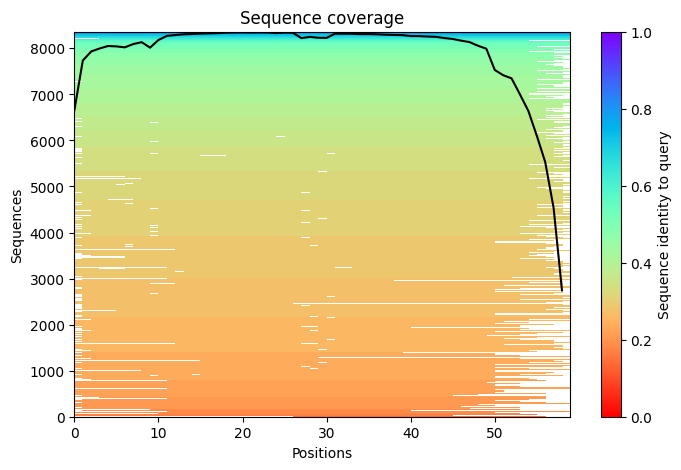

2025-08-02 15:24:48,562 Setting max_seq=512, max_extra_seq=5120
2025-08-02 15:25:27,321 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=96.6 pTM=0.755
2025-08-02 15:25:50,300 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=96.5 pTM=0.759 tol=0.286
2025-08-02 15:25:55,122 alphafold2_ptm_model_1_seed_000 recycle=2 pLDDT=96.2 pTM=0.755 tol=0.0367
2025-08-02 15:25:59,974 alphafold2_ptm_model_1_seed_000 recycle=3 pLDDT=96 pTM=0.755 tol=0.0381
2025-08-02 15:25:59,974 alphafold2_ptm_model_1_seed_000 took 58.6s (3 recycles)


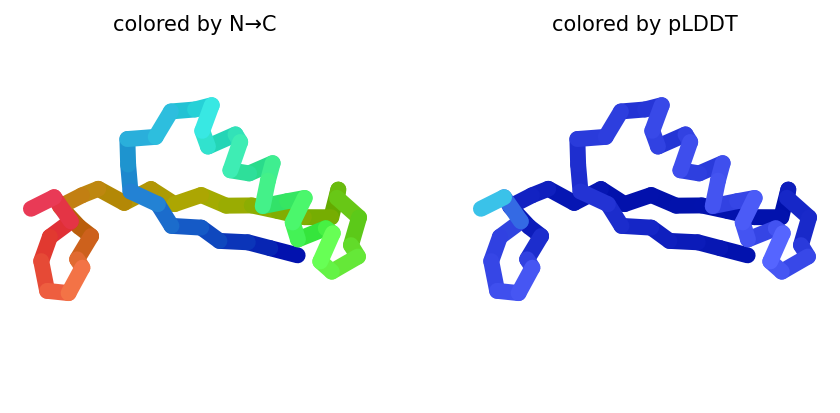

2025-08-02 15:26:04,953 alphafold2_ptm_model_2_seed_000 recycle=0 pLDDT=97 pTM=0.761
2025-08-02 15:26:09,857 alphafold2_ptm_model_2_seed_000 recycle=1 pLDDT=97 pTM=0.766 tol=0.368
2025-08-02 15:26:14,789 alphafold2_ptm_model_2_seed_000 recycle=2 pLDDT=96.9 pTM=0.766 tol=0.142
2025-08-02 15:26:19,746 alphafold2_ptm_model_2_seed_000 recycle=3 pLDDT=96.8 pTM=0.768 tol=0.0666
2025-08-02 15:26:19,747 alphafold2_ptm_model_2_seed_000 took 19.7s (3 recycles)


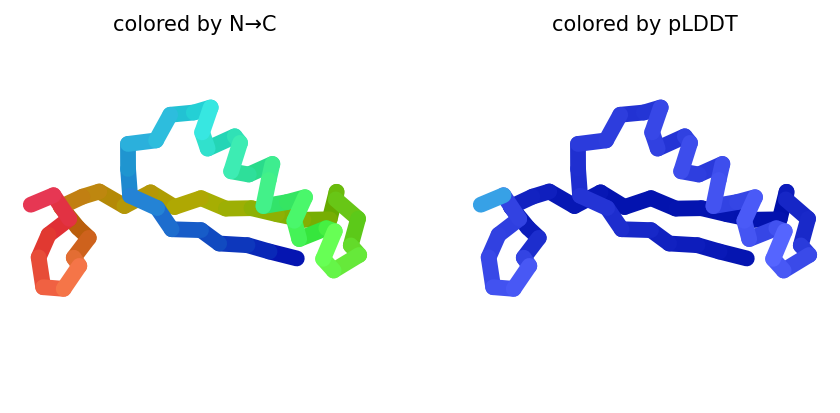

2025-08-02 15:26:24,811 alphafold2_ptm_model_3_seed_000 recycle=0 pLDDT=97.2 pTM=0.775
2025-08-02 15:26:29,818 alphafold2_ptm_model_3_seed_000 recycle=1 pLDDT=97.4 pTM=0.782 tol=0.297
2025-08-02 15:26:34,855 alphafold2_ptm_model_3_seed_000 recycle=2 pLDDT=97.4 pTM=0.781 tol=0.125
2025-08-02 15:26:39,913 alphafold2_ptm_model_3_seed_000 recycle=3 pLDDT=97.4 pTM=0.784 tol=0.0448
2025-08-02 15:26:39,914 alphafold2_ptm_model_3_seed_000 took 20.1s (3 recycles)


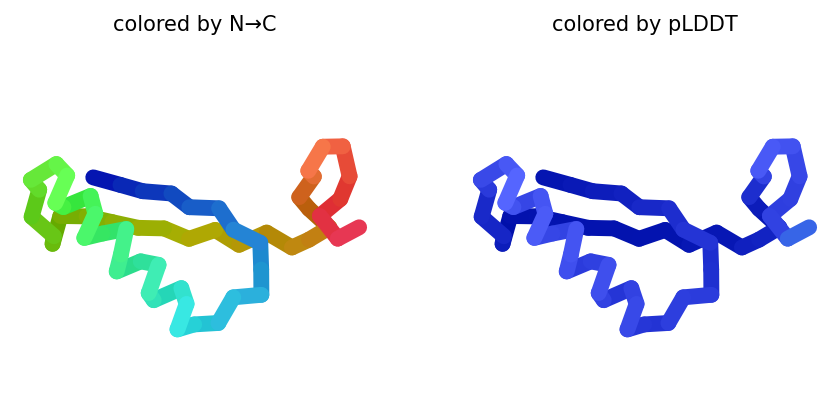

2025-08-02 15:26:45,089 alphafold2_ptm_model_4_seed_000 recycle=0 pLDDT=97.4 pTM=0.774
2025-08-02 15:26:50,153 alphafold2_ptm_model_4_seed_000 recycle=1 pLDDT=97.4 pTM=0.781 tol=0.312
2025-08-02 15:26:55,183 alphafold2_ptm_model_4_seed_000 recycle=2 pLDDT=97.1 pTM=0.777 tol=0.111
2025-08-02 15:27:00,201 alphafold2_ptm_model_4_seed_000 recycle=3 pLDDT=96.9 pTM=0.777 tol=0.0358
2025-08-02 15:27:00,201 alphafold2_ptm_model_4_seed_000 took 20.2s (3 recycles)


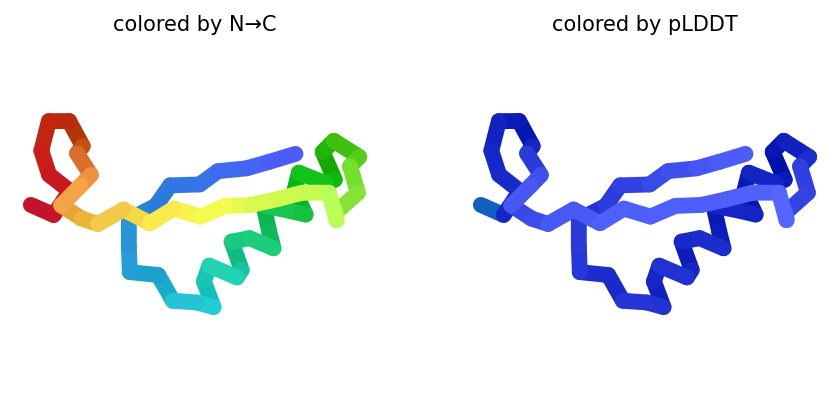

2025-08-02 15:27:05,269 alphafold2_ptm_model_5_seed_000 recycle=0 pLDDT=97.4 pTM=0.784
2025-08-02 15:27:10,268 alphafold2_ptm_model_5_seed_000 recycle=1 pLDDT=96.9 pTM=0.783 tol=0.268
2025-08-02 15:27:15,242 alphafold2_ptm_model_5_seed_000 recycle=2 pLDDT=96.1 pTM=0.774 tol=0.201
2025-08-02 15:27:20,202 alphafold2_ptm_model_5_seed_000 recycle=3 pLDDT=96.2 pTM=0.778 tol=0.0956
2025-08-02 15:27:20,202 alphafold2_ptm_model_5_seed_000 took 19.9s (3 recycles)


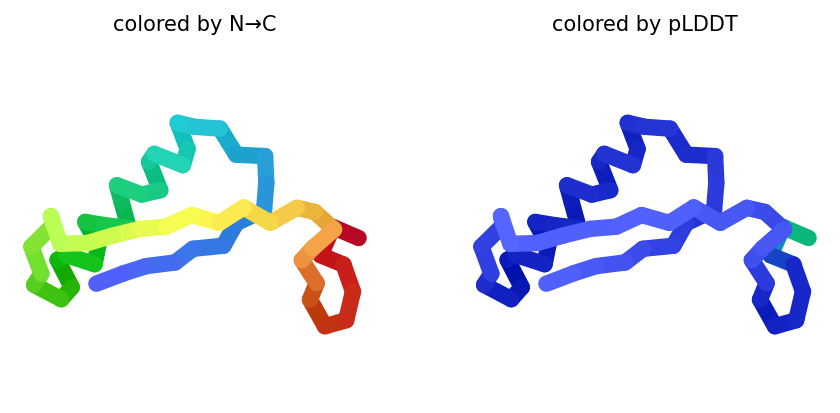

2025-08-02 15:27:20,279 reranking models by 'plddt' metric
2025-08-02 15:27:20,280 rank_001_alphafold2_ptm_model_3_seed_000 pLDDT=97.4 pTM=0.784
2025-08-02 15:27:20,280 rank_002_alphafold2_ptm_model_4_seed_000 pLDDT=96.9 pTM=0.777
2025-08-02 15:27:20,280 rank_003_alphafold2_ptm_model_2_seed_000 pLDDT=96.8 pTM=0.768
2025-08-02 15:27:20,280 rank_004_alphafold2_ptm_model_5_seed_000 pLDDT=96.2 pTM=0.778
2025-08-02 15:27:20,281 rank_005_alphafold2_ptm_model_1_seed_000 pLDDT=96 pTM=0.755
2025-08-02 15:27:21,255 Done


0

In [ ]:
#@title Run Prediction
display_images = True #@param {type:"boolean"}

import sys
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from Bio import BiopythonDeprecationWarning
warnings.simplefilter(action='ignore', category=BiopythonDeprecationWarning)
from pathlib import Path
from colabfold.download import download_alphafold_params, default_data_dir
from colabfold.utils import setup_logging
from colabfold.batch import get_queries, run, set_model_type
from colabfold.plot import plot_msa_v2

import os
import numpy as np
try:
  K80_chk = os.popen('nvidia-smi | grep "Tesla K80" | wc -l').read()
except:
  K80_chk = "0"
  pass
if "1" in K80_chk:
  print("WARNING: found GPU Tesla K80: limited to total length < 1000")
  if "TF_FORCE_UNIFIED_MEMORY" in os.environ:
    del os.environ["TF_FORCE_UNIFIED_MEMORY"]
  if "XLA_PYTHON_CLIENT_MEM_FRACTION" in os.environ:
    del os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]

from colabfold.colabfold import plot_protein
from pathlib import Path
import matplotlib.pyplot as plt

# For some reason we need that to get pdbfixer to import
if use_amber and f"/usr/local/lib/python{python_version}/site-packages/" not in sys.path:
    sys.path.insert(0, f"/usr/local/lib/python{python_version}/site-packages/")

def input_features_callback(input_features):
  if display_images:
    plot_msa_v2(input_features)
    plt.show()
    plt.close()

def prediction_callback(protein_obj, length,
                        prediction_result, input_features, mode):
  model_name, relaxed = mode
  if not relaxed:
    if display_images:
      fig = plot_protein(protein_obj, Ls=length, dpi=150)
      plt.show()
      plt.close()

result_dir = jobname
log_filename = os.path.join(jobname,"log.txt")
setup_logging(Path(log_filename))

queries, is_complex = get_queries(queries_path)
model_type = set_model_type(is_complex, model_type)

if "multimer" in model_type and max_msa is not None:
  use_cluster_profile = False
else:
  use_cluster_profile = True

download_alphafold_params(model_type, Path("."))
results = run(
    queries=queries,
    result_dir=result_dir,
    use_templates=use_templates,
    custom_template_path=custom_template_path,
    num_relax=num_relax,
    msa_mode=msa_mode,
    model_type=model_type,
    num_models=5,
    num_recycles=num_recycles,
    relax_max_iterations=relax_max_iterations,
    recycle_early_stop_tolerance=recycle_early_stop_tolerance,
    num_seeds=num_seeds,
    use_dropout=use_dropout,
    model_order=[1,2,3,4,5],
    is_complex=is_complex,
    data_dir=Path("."),
    keep_existing_results=False,
    rank_by="auto",
    pair_mode=pair_mode,
    pairing_strategy=pairing_strategy,
    stop_at_score=float(100),
    prediction_callback=prediction_callback,
    dpi=dpi,
    zip_results=False,
    save_all=save_all,
    max_msa=max_msa,
    use_cluster_profile=use_cluster_profile,
    input_features_callback=input_features_callback,
    save_recycles=save_recycles,
    user_agent="colabfold/google-colab-main",
)
results_zip = f"{jobname}.result.zip"
os.system(f"zip -r {results_zip} {jobname}")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

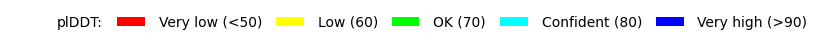

In [ ]:
#@title Display 3D structure {run: "auto"}
import py3Dmol
import glob
import matplotlib.pyplot as plt
from colabfold.colabfold import plot_plddt_legend
from colabfold.colabfold import pymol_color_list, alphabet_list
rank_num = 1 #@param ["1", "2", "3", "4", "5"] {type:"raw"}
color = "lDDT" #@param ["chain", "lDDT", "rainbow"]
show_sidechains = False #@param {type:"boolean"}
show_mainchains = False #@param {type:"boolean"}

tag = results["rank"][0][rank_num - 1]
jobname_prefix = ".custom" if msa_mode == "custom" else ""
pdb_filename = f"{jobname}/{jobname}{jobname_prefix}_unrelaxed_{tag}.pdb"
pdb_file = glob.glob(pdb_filename)

def show_pdb(rank_num=1, show_sidechains=False, show_mainchains=False, color="lDDT"):
  model_name = f"rank_{rank_num}"
  view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js',)
  view.addModel(open(pdb_file[0],'r').read(),'pdb')

  if color == "lDDT":
    view.setStyle({'cartoon': {'colorscheme': {'prop':'b','gradient': 'roygb','min':50,'max':90}}})
  elif color == "rainbow":
    view.setStyle({'cartoon': {'color':'spectrum'}})
  elif color == "chain":
    chains = len(queries[0][1]) + 1 if is_complex else 1
    for n,chain,color in zip(range(chains),alphabet_list,pymol_color_list):
       view.setStyle({'chain':chain},{'cartoon': {'color':color}})

  if show_sidechains:
    BB = ['C','O','N']
    view.addStyle({'and':[{'resn':["GLY","PRO"],'invert':True},{'atom':BB,'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"GLY"},{'atom':'CA'}]},
                        {'sphere':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
    view.addStyle({'and':[{'resn':"PRO"},{'atom':['C','O'],'invert':True}]},
                        {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
  if show_mainchains:
    BB = ['C','O','N','CA']
    view.addStyle({'atom':BB},{'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})

  view.zoomTo()
  return view

show_pdb(rank_num, show_sidechains, show_mainchains, color).show()
if color == "lDDT":
  plot_plddt_legend().show()


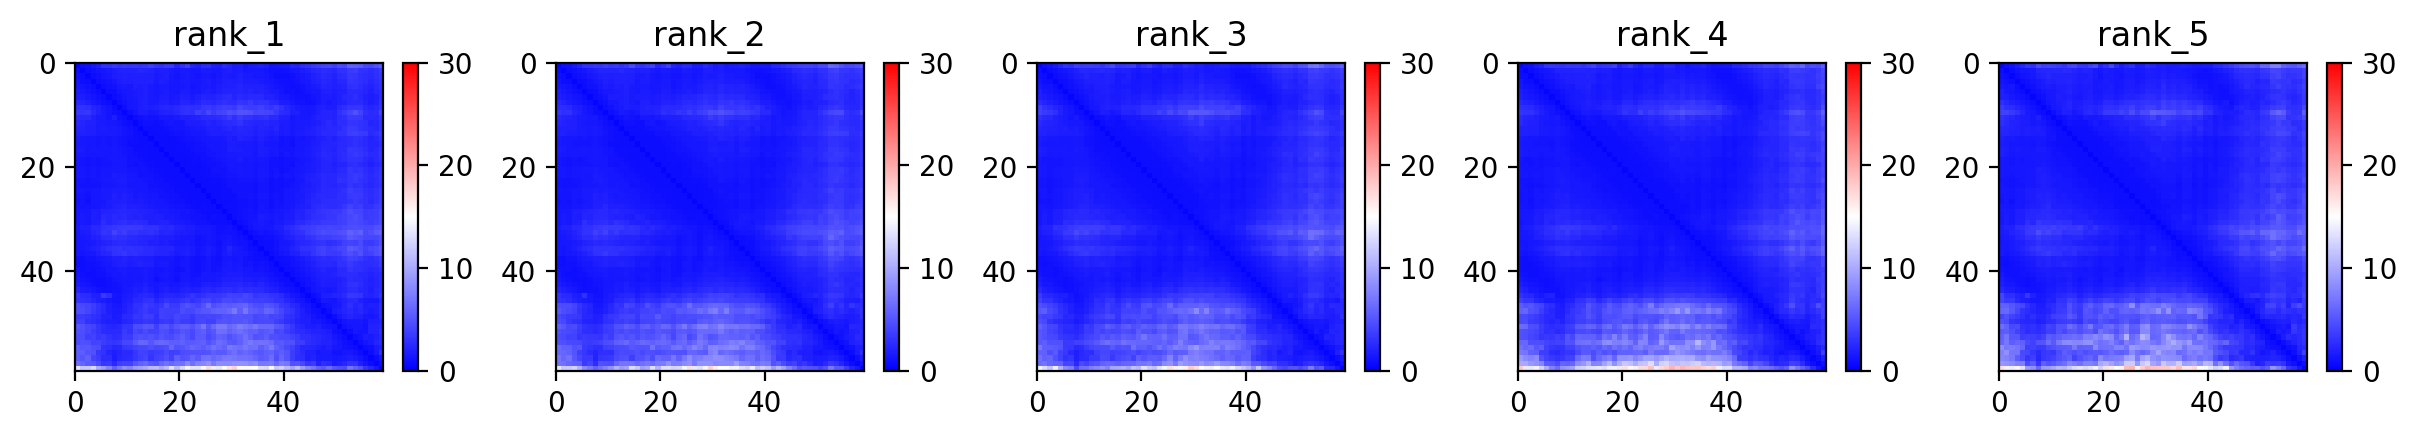
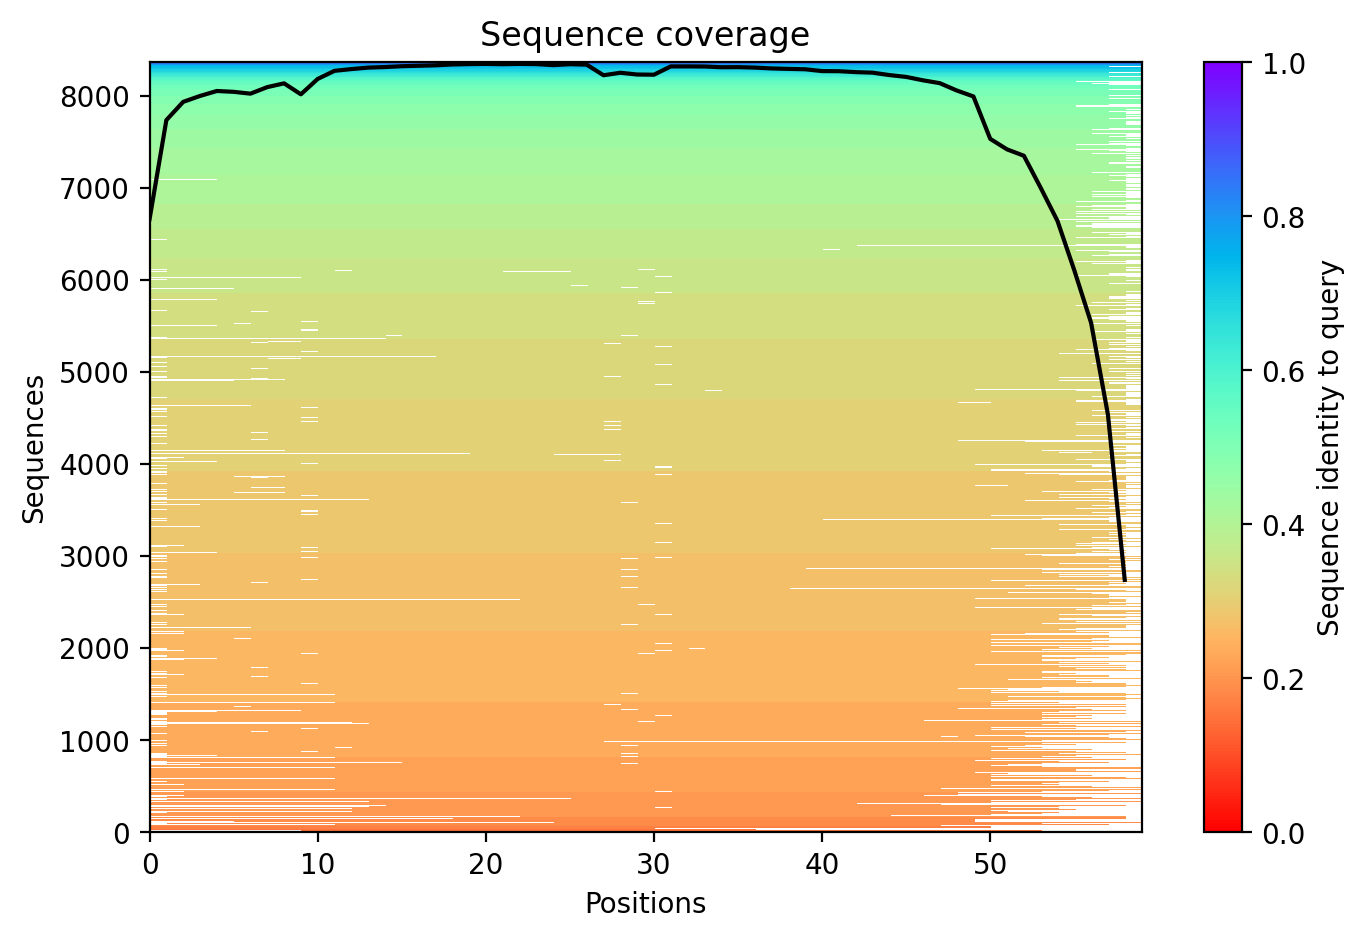
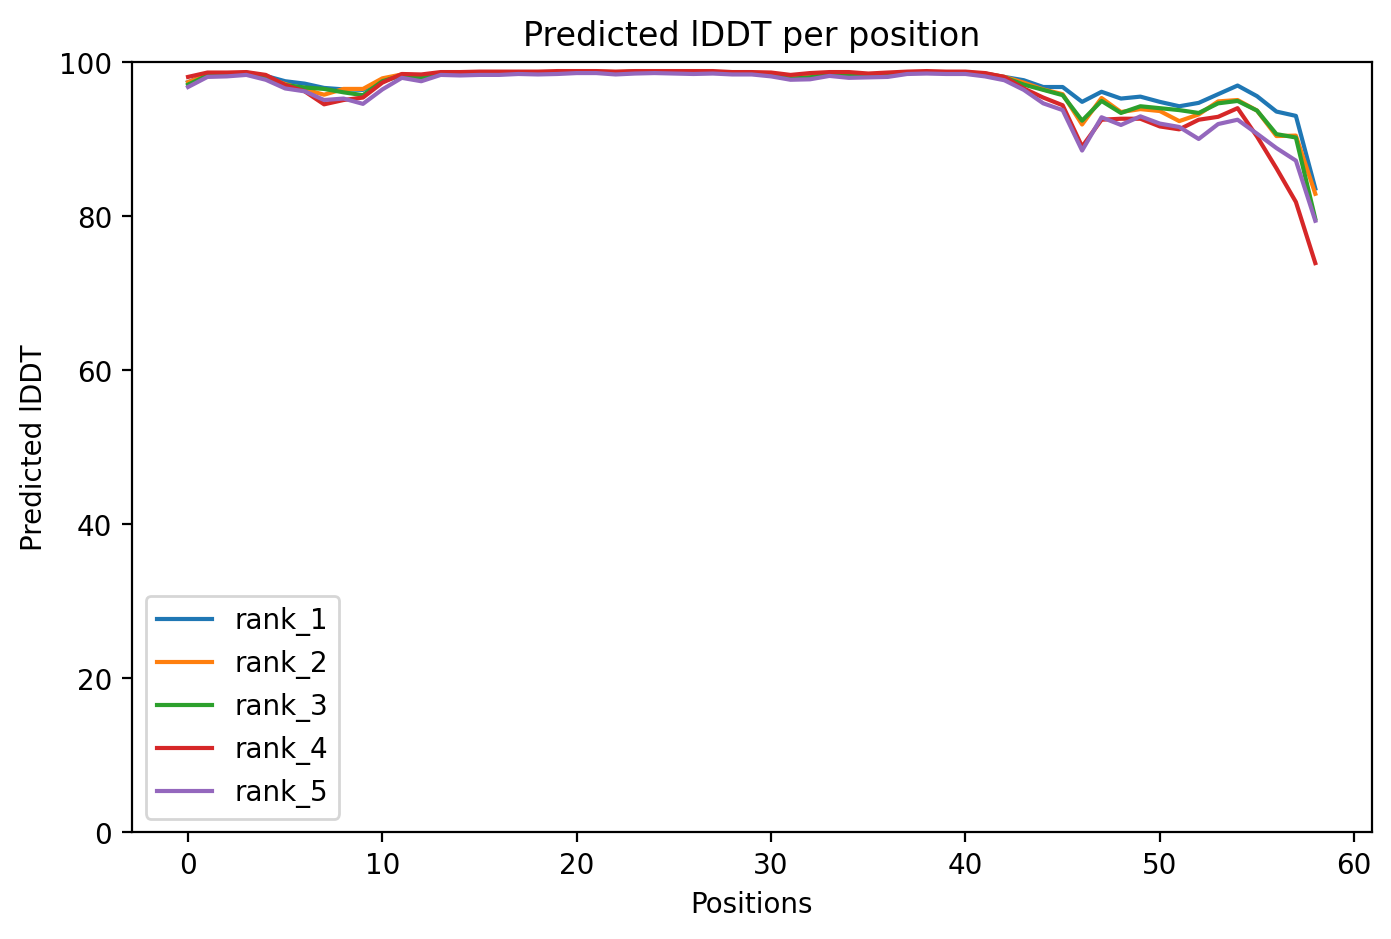

In [ ]:
#@title Plots {run: "auto"}
from IPython.display import display, HTML
import base64
from html import escape

# see: https://stackoverflow.com/a/53688522
def image_to_data_url(filename):
  ext = filename.split('.')[-1]
  prefix = f'data:image/{ext};base64,'
  with open(filename, 'rb') as f:
    img = f.read()
  return prefix + base64.b64encode(img).decode('utf-8')

pae = ""
pae_file = os.path.join(jobname,f"{jobname}{jobname_prefix}_pae.png")
if os.path.isfile(pae_file):
    pae = image_to_data_url(pae_file)
cov = image_to_data_url(os.path.join(jobname,f"{jobname}{jobname_prefix}_coverage.png"))
plddt = image_to_data_url(os.path.join(jobname,f"{jobname}{jobname_prefix}_plddt.png"))
display(HTML(f"""
<style>
  img {{
    float:left;
  }}
  .full {{
    max-width:100%;
  }}
  .half {{
    max-width:50%;
  }}
  @media (max-width:640px) {{
    .half {{
      max-width:100%;
    }}
  }}
</style>
<div style="max-width:90%; padding:2em;">
  <h1>Plots for {escape(jobname)}</h1>
  { '<!--' if pae == '' else '' }<img src="{pae}" class="full" />{ '-->' if pae == '' else '' }
  <img src="{cov}" class="half" />
  <img src="{plddt}" class="half" />
</div>
"""))


In [ ]:
#@title Package and download results
#@markdown If you are having issues downloading the result archive, try disabling your adblocker and run this cell again. If that fails click on the little folder icon to the left, navigate to file: `jobname.result.zip`, right-click and select \"Download\" (see [screenshot](https://pbs.twimg.com/media/E6wRW2lWUAEOuoe?format=jpg&name=small)).

if msa_mode == "custom":
  print("Don't forget to cite your custom MSA generation method.")

files.download(f"{jobname}.result.zip")

if save_to_google_drive == True and drive:
  uploaded = drive.CreateFile({'title': f"{jobname}.result.zip"})
  uploaded.SetContentFile(f"{jobname}.result.zip")
  uploaded.Upload()
  print(f"Uploaded {jobname}.result.zip to Google Drive with ID {uploaded.get('id')}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ColabFold: Multi-FASTA Mode

This section runs the **modified ColabFold pipeline** developed at GaTe Lab (USP) as part of the FRALCAT project, which allows batch prediction using a **Multi-FASTA file**.

📄 Your input should be a FASTA file containing multiple **amino acid sequences**, stored in your **Google Drive**.

📁 Provide the full path to your file in Drive, for example:  
`/content/drive/MyDrive/ColabFold_FRALCAT/my_sequences.fasta`

🔁 The script will loop through each sequence in the file and run AlphaFold2 individually.

⚠️ **Important**: Only run this section **after** completing the Single-Sequence setup above, so all dependencies are properly installed.


jobname SP78_46_47_48_TRINITY_DN29318_c0_g1_i4_0_0d597
sequence MSRGGSHGELGQRIDYVFKVVLIGDSAVGKSQLLARFARNEFNLDSKATIGVEFQTRTLNIDARTVKAQIWDTAGQERYRAVTSAYYRGAVGAMLVYDITKRQSFDHVARWLEELRGHADKNIVIMLIGNKSDLGTLRAVPTEDAKEFAERENLFFMETSALESINVENAFMTVLTEIYRIVSKKNLVANEESDSSGNSSLLKGTKIVVPGQEPPPTSKATCCMSS
length 226
2025-08-02 15:27:32,302 Failure refreshing credentials: ("Failed to retrieve http://metadata.google.internal/computeMetadata/v1/instance/service-accounts/default/?recursive=true from the Google Compute Engine metadata service. Status: 404 Response:\nb''", <google.auth.transport.requests._Response object at 0x7cedbb0df810>)
2025-08-02 15:27:32,558 Failure refreshing credentials: ("Failed to retrieve http://metadata.google.internal/computeMetadata/v1/instance/service-accounts/default/?recursive=true from the Google Compute Engine metadata service. Status: 404 Response:\nb''", <google.auth.transport.requests._Response object at 0x7cfdf86cc750>)
You are logged into Google Drive and are good to

COMPLETE: 100%|██████████| 150/150 [elapsed: 00:07 remaining: 00:00]


2025-08-02 15:28:25,667 Setting max_seq=512, max_extra_seq=5120
2025-08-02 15:29:34,386 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=80.2 pTM=0.731
2025-08-02 15:30:14,779 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=80.7 pTM=0.735 tol=3.41
2025-08-02 15:30:33,519 alphafold2_ptm_model_1_seed_000 recycle=2 pLDDT=80.5 pTM=0.735 tol=1.31
2025-08-02 15:30:52,040 alphafold2_ptm_model_1_seed_000 recycle=3 pLDDT=80.7 pTM=0.735 tol=2.73
2025-08-02 15:30:52,041 alphafold2_ptm_model_1_seed_000 took 128.9s (3 recycles)
2025-08-02 15:31:10,479 alphafold2_ptm_model_2_seed_000 recycle=0 pLDDT=81.9 pTM=0.748
2025-08-02 15:31:28,897 alphafold2_ptm_model_2_seed_000 recycle=1 pLDDT=81.3 pTM=0.75 tol=4.49
2025-08-02 15:31:47,416 alphafold2_ptm_model_2_seed_000 recycle=2 pLDDT=81.1 pTM=0.747 tol=0.547
2025-08-02 15:32:06,012 alphafold2_ptm_model_2_seed_000 recycle=3 pLDDT=80.9 pTM=0.749 tol=2.38
2025-08-02 15:32:06,012 alphafold2_ptm_model_2_seed_000 took 73.9s (3 recycles)
2025-08-02 15:32:24,607 a

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

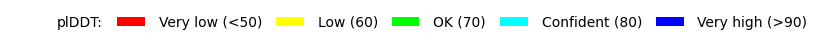

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Uploaded SP78_46_47_48_TRINITY_DN29318_c0_g1_i4_0_0d597.result.zip to Google Drive with ID 1W_qD0A-aslrTZrTN_h8Ow9LI9FBE8fcS
jobname CB49_13_14_15_TRINITY_DN1912_c1_g1_i1_0_3a462
sequence SSSLALASGISASPSAAASTARHRHGGAPQQLRVKAAVRPQQQLLHGGRRHTRGSAVVVRAGPGPLSEIEPDLEEDAIDVYRTNGIAPEDFVFGKYDGHHTYFETQDKKGFWEDVSEWYQEAEPPQGFQALISWAFPPAIILGMAFNVPGEYLYIGAAVFIVVFCIFEMRKPDKPHNFEPEIYMMERSARDKLIADYNSMDIWDFNEKYGELWDFTVNPRDDIVKST
length 227
You are logged into Google Drive and are good to go!
2025-08-02 15:35:54,900 Running on GPU
2025-08-02 15:35:54,903 Found 5 citations for tools or databases
2025-08-02 15:35:54,904 Query 1/1: CB49_13_14_15_TRINITY_DN1912_c1_g1_i1_0_3a462 (length 227)


PENDING:   0%|          | 0/150 [elapsed: 00:02 remaining: ?]

2025-08-02 15:35:57,057 Sleeping for 5s. Reason: PENDING


...

RUNNING:  25%|██▍       | 37/150 [elapsed: 00:51 remaining: 02:33]

2025-08-02 15:36:46,369 Sleeping for 9s. Reason: RUNNING


COMPLETE: 100%|██████████| 150/150 [elapsed: 01:05 remaining: 00:00]


2025-08-02 15:37:00,957 Setting max_seq=284, max_extra_seq=1
2025-08-02 15:37:40,142 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=56.5 pTM=0.281
2025-08-02 15:38:10,878 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=54.9 pTM=0.282 tol=7.36
2025-08-02 15:38:21,086 alphafold2_ptm_model_1_seed_000 recycle=2 pLDDT=54.9 pTM=0.286 tol=5
2025-08-02 15:38:31,286 alphafold2_ptm_model_1_seed_000 recycle=3 pLDDT=54.3 pTM=0.281 tol=4.43
2025-08-02 15:38:31,287 alphafold2_ptm_model_1_seed_000 took 84.8s (3 recycles)
2025-08-02 15:38:41,499 alphafold2_ptm_model_2_seed_000 recycle=0 pLDDT=59.3 pTM=0.28
2025-08-02 15:38:51,533 alphafold2_ptm_model_2_seed_000 recycle=1 pLDDT=57.8 pTM=0.26 tol=10.8
2025-08-02 15:39:01,495 alphafold2_ptm_model_2_seed_000 recycle=2 pLDDT=58.1 pTM=0.273 tol=4.77
2025-08-02 15:39:11,410 alphafold2_ptm_model_2_seed_000 recycle=3 pLDDT=58.2 pTM=0.276 tol=3
2025-08-02 15:39:11,411 alphafold2_ptm_model_2_seed_000 took 40.1s (3 recycles)
2025-08-02 15:39:21,387 alphafold2_pt

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

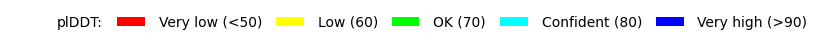

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Uploaded CB49_13_14_15_TRINITY_DN1912_c1_g1_i1_0_3a462.result.zip to Google Drive with ID 18n-B1wncisu4dEHE682zC10uCQWqe5iI
jobname SP80_19_20_21_TRINITY_DN9652_c0_g1_i4_0_22d93
sequence MRHPLLDPPRGEASPPSTAAPRRPSASLGLQIPTLAMSGRRQAWQFAAALVFFHGSEYVLAAAFHGRQNVTATSLLISKQYVLAMGFAMLEHLTEILIFPEVKEYWFVSNTGLLMVIIGEIIRKLAVVTAGRSFTHVIRTYYEDQHQLITHGLYRFMRHPGYSGFLIWAVGTQVMLCNPLSTVAFTLVLWRFFSKRIPYEEFFLRQFFGSEYDEYARRVHSGLPFIK
length 227
You are logged into Google Drive and are good to go!
2025-08-02 15:41:18,124 Running on GPU
2025-08-02 15:41:18,127 Found 5 citations for tools or databases
2025-08-02 15:41:18,127 Query 1/1: SP80_19_20_21_TRINITY_DN9652_c0_g1_i4_0_22d93 (length 227)


PENDING:   0%|          | 0/150 [elapsed: 00:01 remaining: ?]

2025-08-02 15:41:19,835 Sleeping for 10s. Reason: PENDING


...

RUNNING:  26%|██▌       | 39/150 [elapsed: 00:54 remaining: 02:28]

2025-08-02 15:42:12,921 Sleeping for 10s. Reason: RUNNING


COMPLETE: 100%|██████████| 150/150 [elapsed: 01:11 remaining: 00:00]


2025-08-02 15:42:30,361 Setting max_seq=512, max_extra_seq=5120
2025-08-02 15:43:30,358 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=88 pTM=0.793
2025-08-02 15:44:11,078 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=87.8 pTM=0.799 tol=4.52
2025-08-02 15:44:30,153 alphafold2_ptm_model_1_seed_000 recycle=2 pLDDT=88.2 pTM=0.799 tol=1.72
2025-08-02 15:44:49,076 alphafold2_ptm_model_1_seed_000 recycle=3 pLDDT=88.2 pTM=0.798 tol=0.785
2025-08-02 15:44:49,076 alphafold2_ptm_model_1_seed_000 took 129.5s (3 recycles)
2025-08-02 15:45:07,816 alphafold2_ptm_model_2_seed_000 recycle=0 pLDDT=88.6 pTM=0.801
2025-08-02 15:45:26,498 alphafold2_ptm_model_2_seed_000 recycle=1 pLDDT=89 pTM=0.806 tol=3.92
2025-08-02 15:45:45,277 alphafold2_ptm_model_2_seed_000 recycle=2 pLDDT=88.6 pTM=0.804 tol=0.709
2025-08-02 15:46:04,078 alphafold2_ptm_model_2_seed_000 recycle=3 pLDDT=88.8 pTM=0.805 tol=0.577
2025-08-02 15:46:04,079 alphafold2_ptm_model_2_seed_000 took 74.9s (3 recycles)
2025-08-02 15:46:22,895 al

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

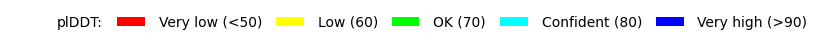

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Uploaded SP80_19_20_21_TRINITY_DN9652_c0_g1_i4_0_22d93.result.zip to Google Drive with ID 16f7o3clrqE8eHonKcZlmBilchESSEynq
jobname CB49_13_14_15_TRINITY_DN7331_c0_g1_i7_0_362f9
sequence SKVPVTLVAQIRSRKKLLVLDLNGLLADINRDSHNAHLSHGRCRGKLVFKRPFCDDFLKFCFRNFDVGVWSSRQRVNVDAAVDILMKDFIHRLLFSWDASKCSATGLYTLENKNKPLVLKELKELWSKEEADGLPWQQGEFSPSNTLLVDDSPYKALRNPPHTAIFPYPYSYKNRKNDSSLGPGGDLRLYLEGLATADDVSRFVREHPFGQPPITQTDPNWNFYKRVL
length 228
You are logged into Google Drive and are good to go!
2025-08-02 15:49:56,042 Running on GPU
2025-08-02 15:49:56,045 Found 5 citations for tools or databases
2025-08-02 15:49:56,046 Query 1/1: CB49_13_14_15_TRINITY_DN7331_c0_g1_i7_0_362f9 (length 228)


PENDING:   0%|          | 0/150 [elapsed: 00:02 remaining: ?]

2025-08-02 15:49:58,638 Sleeping for 5s. Reason: PENDING


...

RUNNING:  18%|█▊        | 27/150 [elapsed: 00:41 remaining: 03:02]

2025-08-02 15:50:37,520 Sleeping for 5s. Reason: RUNNING


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:54 remaining: 00:00]


2025-08-02 15:50:50,844 Setting max_seq=512, max_extra_seq=1956
2025-08-02 15:51:39,209 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=90.7 pTM=0.875
2025-08-02 15:52:14,019 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=91.6 pTM=0.882 tol=0.614
2025-08-02 15:52:31,054 alphafold2_ptm_model_1_seed_000 recycle=2 pLDDT=91.6 pTM=0.882 tol=0.399
2025-08-02 15:52:47,977 alphafold2_ptm_model_1_seed_000 recycle=3 pLDDT=91.7 pTM=0.883 tol=0.374
2025-08-02 15:52:47,978 alphafold2_ptm_model_1_seed_000 took 110.9s (3 recycles)
2025-08-02 15:53:04,853 alphafold2_ptm_model_2_seed_000 recycle=0 pLDDT=90.9 pTM=0.882
2025-08-02 15:53:21,687 alphafold2_ptm_model_2_seed_000 recycle=1 pLDDT=91.8 pTM=0.89 tol=0.397
2025-08-02 15:53:38,496 alphafold2_ptm_model_2_seed_000 recycle=2 pLDDT=91.9 pTM=0.891 tol=0.343
2025-08-02 15:53:55,374 alphafold2_ptm_model_2_seed_000 recycle=3 pLDDT=92 pTM=0.892 tol=0.219
2025-08-02 15:53:55,375 alphafold2_ptm_model_2_seed_000 took 67.3s (3 recycles)
2025-08-02 15:54:12,39

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

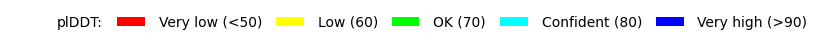

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Uploaded CB49_13_14_15_TRINITY_DN7331_c0_g1_i7_0_362f9.result.zip to Google Drive with ID 1EpPq845CJ9Fu_0Y3Ifu5xmDEjrVnzJxv
jobname CB49_16_17_18_TRINITY_DN11710_c0_g1_i12_0_acd1e
sequence MAAAALRSSAARRLLRLAPAASPALSFASRPTAGVAPLSRPIAALSGGNHPISWKLRRFFSSNEKHLPAISDPEIESAFKDLLAASWNELPDSLVAEAKKAVSKATDDKAGQEALKNVFRAAEACEEFSGTLVTLRMALDDLCGLTGENVGPLPGYIEDAVKAAYNRYMTYLESFGPEENYLRKKVETELGTKMIHLKMRCSGIGSEWGKISLIGTSGISGSYVELRA
length 228
You are logged into Google Drive and are good to go!
2025-08-02 15:57:24,267 Running on GPU
2025-08-02 15:57:24,270 Found 5 citations for tools or databases
2025-08-02 15:57:24,270 Query 1/1: CB49_16_17_18_TRINITY_DN11710_c0_g1_i12_0_acd1e (length 228)


PENDING:   0%|          | 0/150 [elapsed: 00:02 remaining: ?]

2025-08-02 15:57:26,393 Sleeping for 5s. Reason: PENDING


...

RUNNING:  15%|█▌        | 23/150 [elapsed: 00:33 remaining: 02:57]

2025-08-02 15:57:57,689 Sleeping for 5s. Reason: RUNNING


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:43 remaining: 00:00]


2025-08-02 15:58:08,313 Setting max_seq=350, max_extra_seq=1
2025-08-02 15:58:46,423 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=67.4 pTM=0.567
2025-08-02 15:59:15,962 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=64.6 pTM=0.555 tol=5.71
2025-08-02 15:59:27,653 alphafold2_ptm_model_1_seed_000 recycle=2 pLDDT=64 pTM=0.546 tol=3.95
2025-08-02 15:59:39,206 alphafold2_ptm_model_1_seed_000 recycle=3 pLDDT=64.3 pTM=0.559 tol=2.57
2025-08-02 15:59:39,207 alphafold2_ptm_model_1_seed_000 took 84.6s (3 recycles)
2025-08-02 15:59:50,687 alphafold2_ptm_model_2_seed_000 recycle=0 pLDDT=70.1 pTM=0.59
2025-08-02 16:00:02,060 alphafold2_ptm_model_2_seed_000 recycle=1 pLDDT=70 pTM=0.597 tol=5.76
2025-08-02 16:00:13,414 alphafold2_ptm_model_2_seed_000 recycle=2 pLDDT=69.2 pTM=0.594 tol=1.78
2025-08-02 16:00:24,852 alphafold2_ptm_model_2_seed_000 recycle=3 pLDDT=68.8 pTM=0.591 tol=2.38
2025-08-02 16:00:24,853 alphafold2_ptm_model_2_seed_000 took 45.6s (3 recycles)
2025-08-02 16:00:36,425 alphafold2

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

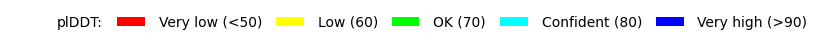

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Uploaded CB49_16_17_18_TRINITY_DN11710_c0_g1_i12_0_acd1e.result.zip to Google Drive with ID 1QwwJSyxfeI6GmUe9U0fjYWafbPnfbQVn
jobname CB49_16_17_18_TRINITY_DN119185_c0_g1_i5_0_dbeb1
sequence EKAVKLLGMWASPYVLQVKWALAMKGVEYEYVEEDLRSKSAELLAYNPVHKKVPVLVYHGKPLAESQVILEFIDEAWNHRGDRILPHDPYQRAMARFWARFQHDKLSLPIWRWFTTEGEEQEAAYEAAVEQLLVLEKELAVAGKPFFGGEKVGFVDLSLGPLSYVIPMYEEIVTGGGGGGGVKMVTEEKMPSLAAWMGRFLSSPAVRDHLPPLEKLRPRYQAMRESFL
length 228
You are logged into Google Drive and are good to go!
2025-08-02 16:02:48,685 Running on GPU
2025-08-02 16:02:48,688 Found 5 citations for tools or databases
2025-08-02 16:02:48,688 Query 1/1: CB49_16_17_18_TRINITY_DN119185_c0_g1_i5_0_dbeb1 (length 228)


PENDING:   0%|          | 0/150 [elapsed: 00:02 remaining: ?]

2025-08-02 16:02:51,070 Sleeping for 8s. Reason: PENDING


...

RUNNING:  35%|███▌      | 53/150 [elapsed: 01:19 remaining: 02:21]

2025-08-02 16:04:08,433 Sleeping for 9s. Reason: RUNNING


COMPLETE: 100%|██████████| 150/150 [elapsed: 01:35 remaining: 00:00]


2025-08-02 16:04:25,259 Setting max_seq=512, max_extra_seq=5120
2025-08-02 16:05:22,464 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=92.6 pTM=0.896
2025-08-02 16:05:59,854 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=93.4 pTM=0.898 tol=0.439
2025-08-02 16:06:18,714 alphafold2_ptm_model_1_seed_000 recycle=2 pLDDT=93.6 pTM=0.898 tol=0.107
2025-08-02 16:06:37,419 alphafold2_ptm_model_1_seed_000 recycle=3 pLDDT=93.9 pTM=0.898 tol=0.317
2025-08-02 16:06:37,420 alphafold2_ptm_model_1_seed_000 took 121.6s (3 recycles)
2025-08-02 16:06:56,055 alphafold2_ptm_model_2_seed_000 recycle=0 pLDDT=92.7 pTM=0.9
2025-08-02 16:07:14,480 alphafold2_ptm_model_2_seed_000 recycle=1 pLDDT=93.5 pTM=0.905 tol=0.401
2025-08-02 16:07:32,965 alphafold2_ptm_model_2_seed_000 recycle=2 pLDDT=93.5 pTM=0.903 tol=0.166
2025-08-02 16:07:51,578 alphafold2_ptm_model_2_seed_000 recycle=3 pLDDT=93.6 pTM=0.902 tol=0.098
2025-08-02 16:07:51,579 alphafold2_ptm_model_2_seed_000 took 74.1s (3 recycles)
2025-08-02 16:08:10,2

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

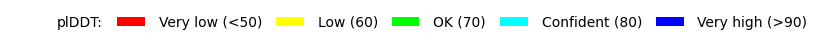

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Uploaded CB49_16_17_18_TRINITY_DN119185_c0_g1_i5_0_dbeb1.result.zip to Google Drive with ID 159SzIRForBsNmkvadMjgz9nZq0TAA2ey
jobname SP80_19_20_21_TRINITY_DN46369_c0_g1_i8_0_c7117
sequence MAGKFGAIRSRAVACLFSPHPRNLFLHSTQTPSRFLPFTRRLHPRSLSTLAMAASNGAAAAATDSVQEPVAAATESVQEPPQKISKISPLLKVKKLSDKAVLPSRGSALAAGYDLSSAVEIVVPARGKALVPTDLSVAIPHGTYARIAPRSGLALKHSIDVGAGVIDADYRGPVGVILFNHSDTDFAVKPGDRIAQMIIEVIATPEVAEVEDLDATVRGEGGFGSTGV
length 228
You are logged into Google Drive and are good to go!
2025-08-02 16:11:40,812 Running on GPU
2025-08-02 16:11:40,815 Found 5 citations for tools or databases
2025-08-02 16:11:40,816 Query 1/1: SP80_19_20_21_TRINITY_DN46369_c0_g1_i8_0_c7117 (length 228)


PENDING:   0%|          | 0/150 [elapsed: 00:03 remaining: ?]

2025-08-02 16:11:44,097 Sleeping for 5s. Reason: PENDING


...

RUNNING:  21%|██▏       | 32/150 [elapsed: 00:46 remaining: 02:43]

2025-08-02 16:12:27,461 Sleeping for 10s. Reason: RUNNING


COMPLETE: 100%|██████████| 150/150 [elapsed: 01:06 remaining: 00:00]


2025-08-02 16:12:49,758 Setting max_seq=512, max_extra_seq=5120
2025-08-02 16:13:37,828 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=73.9 pTM=0.572
2025-08-02 16:14:16,607 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=74.7 pTM=0.582 tol=5.47
2025-08-02 16:14:35,337 alphafold2_ptm_model_1_seed_000 recycle=2 pLDDT=74.9 pTM=0.581 tol=4.65
2025-08-02 16:14:53,761 alphafold2_ptm_model_1_seed_000 recycle=3 pLDDT=74.3 pTM=0.578 tol=1.99
2025-08-02 16:14:53,762 alphafold2_ptm_model_1_seed_000 took 112.4s (3 recycles)
2025-08-02 16:15:12,145 alphafold2_ptm_model_2_seed_000 recycle=0 pLDDT=72.8 pTM=0.557
2025-08-02 16:15:30,523 alphafold2_ptm_model_2_seed_000 recycle=1 pLDDT=73.7 pTM=0.574 tol=7.09
2025-08-02 16:15:48,994 alphafold2_ptm_model_2_seed_000 recycle=2 pLDDT=73.8 pTM=0.576 tol=1.6
2025-08-02 16:16:07,515 alphafold2_ptm_model_2_seed_000 recycle=3 pLDDT=73.9 pTM=0.576 tol=0.638
2025-08-02 16:16:07,516 alphafold2_ptm_model_2_seed_000 took 73.7s (3 recycles)
2025-08-02 16:16:26,069 a

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

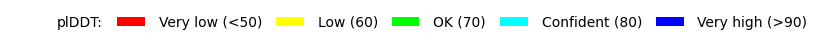

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Uploaded SP80_19_20_21_TRINITY_DN46369_c0_g1_i8_0_c7117.result.zip to Google Drive with ID 1OHdjI-SoRfzFQ-1oUI4257AlKGQaXG5F
jobname SP80_25_26_27_TRINITY_DN9790_c0_g1_i1_0_144ff
sequence TNHVQSAEQHNQDVNSLGLVSARKTAEAVDILKLMSSTYMVALCQAVDLRHLEENLKSAVKNSVMAVARKVLTTTLDGDLHSARFSEKALLTAIDREAVYGYYDDPCSANSPLMKKIRAVLVDHALANGEADKDASASVFSKINRFEETLREVLPREMEAARVAFETGTAPIANRIKESRSYPLYRFIRQDLGAVYLTGEKLKSPGEECNKVFLALSEGKLIDPMLEC
length 228
You are logged into Google Drive and are good to go!
2025-08-02 16:19:55,559 Running on GPU
2025-08-02 16:19:55,562 Found 5 citations for tools or databases
2025-08-02 16:19:55,562 Query 1/1: SP80_25_26_27_TRINITY_DN9790_c0_g1_i1_0_144ff (length 228)


PENDING:   0%|          | 0/150 [elapsed: 00:02 remaining: ?]

2025-08-02 16:19:58,078 Sleeping for 9s. Reason: PENDING


...

RUNNING:  11%|█▏        | 17/150 [elapsed: 00:25 remaining: 03:16]

2025-08-02 16:20:20,775 Sleeping for 5s. Reason: RUNNING


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:35 remaining: 00:00]


2025-08-02 16:20:31,190 Setting max_seq=512, max_extra_seq=1701
2025-08-02 16:21:16,607 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=84.8 pTM=0.767
2025-08-02 16:21:51,197 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=85.8 pTM=0.784 tol=0.591
2025-08-02 16:22:08,110 alphafold2_ptm_model_1_seed_000 recycle=2 pLDDT=86.1 pTM=0.787 tol=0.188
2025-08-02 16:22:24,716 alphafold2_ptm_model_1_seed_000 recycle=3 pLDDT=86.2 pTM=0.787 tol=0.146
2025-08-02 16:22:24,717 alphafold2_ptm_model_1_seed_000 took 106.3s (3 recycles)
2025-08-02 16:22:41,252 alphafold2_ptm_model_2_seed_000 recycle=0 pLDDT=87.2 pTM=0.794
2025-08-02 16:22:57,764 alphafold2_ptm_model_2_seed_000 recycle=1 pLDDT=86.9 pTM=0.799 tol=0.642
2025-08-02 16:23:14,371 alphafold2_ptm_model_2_seed_000 recycle=2 pLDDT=86.7 pTM=0.8 tol=0.434
2025-08-02 16:23:31,055 alphafold2_ptm_model_2_seed_000 recycle=3 pLDDT=86.8 pTM=0.801 tol=0.224
2025-08-02 16:23:31,056 alphafold2_ptm_model_2_seed_000 took 66.3s (3 recycles)
2025-08-02 16:23:47,7

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

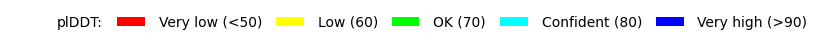

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Uploaded SP80_25_26_27_TRINITY_DN9790_c0_g1_i1_0_144ff.result.zip to Google Drive with ID 1cOKkAe7H4yl4LmhnBNWe4j3rm9_Q3fIY
jobname SP80_31_32_33_TRINITY_DN117_c0_g1_i13_0_b2b45
sequence MANKLATSLLATCFAAAVLLALAAPAVLAGDPDMLQDICVADNKSLKGPLRLNGFPCKRPENVTANDFFSNVLATPGNTGNALGSAVTSANVERLPGLNTLGVSVSRIDYAPWGVNPPHVHPRATEVIFVLQGSLDVGFVTTANRLYARTVCAGEVFVFPRGLVHYQRNNGGGPAAVLSAFDSQLPGTQPVAETLFGASPPVPTDVLARSFLIDGGLVEAIKSKFPPK
length 228
You are logged into Google Drive and are good to go!
2025-08-02 16:26:57,816 Running on GPU
2025-08-02 16:26:57,819 Found 5 citations for tools or databases
2025-08-02 16:26:57,819 Query 1/1: SP80_31_32_33_TRINITY_DN117_c0_g1_i13_0_b2b45 (length 228)


PENDING:   0%|          | 0/150 [elapsed: 00:02 remaining: ?]

2025-08-02 16:27:00,126 Sleeping for 8s. Reason: PENDING


...

2025-08-02 19:57:00,350 Sleeping for 8s. Reason: PENDING


PENDING:   0%|          | 0/150 [elapsed: 3:30:11 remaining: ?]

2025-08-02 19:57:09,551 Sleeping for 8s. Reason: PENDING


PENDING:   0%|          | 0/150 [elapsed: 3:30:20 remaining: ?]

2025-08-02 19:57:18,601 Sleeping for 7s. Reason: PENDING


In [ ]:
# Import necessary libraries
from google.colab import files
import os
import re
import hashlib
import random
from sys import version_info
from pathlib import Path
from Bio import SeqIO
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from Bio import BiopythonDeprecationWarning
warnings.simplefilter(action='ignore', category=BiopythonDeprecationWarning)
from colabfold.download import download_alphafold_params, default_data_dir
from colabfold.utils import setup_logging
from colabfold.batch import get_queries, run, set_model_type
from colabfold.plot import plot_msa_v2
import numpy as np
import matplotlib.pyplot as plt
import py3Dmol
import glob
from colabfold.colabfold import plot_protein, plot_plddt_legend, pymol_color_list, alphabet_list
from IPython.display import display, HTML
import base64
from html import escape

# Define the function to add a hash to the job name
def add_hash(x, y):
    return x + "_" + hashlib.sha1(y.encode()).hexdigest()[:5]

# Function to check if a directory with the job name exists
def check(folder):
    if os.path.exists(folder):
        return False
    else:
        return True

# Update with the path to your multifasta file
fasta_path = "/content/drive/MyDrive/GateLab-ProjetoTT5- Marie Anne/Dados/Dados/contigs_remontados/dados-contigs-remontados/Transcriptoma_remontagem/Transcriptoma_remontagem/Resultados_Egg_NOG/Dados-subconjuntos-diagrama-Venn/Grupo11/grupo11-amino.fasta"#@param {type:"string"}

# Read the multifasta file
for record in SeqIO.parse(fasta_path, "fasta"):
    query_sequence = str(record.seq)
    jobname = record.id

    # Remove whitespaces from the sequence
    query_sequence = "".join(query_sequence.split())

    # Clean the job name by removing special characters
    basejobname = "".join(jobname.split())
    basejobname = re.sub(r'\W+', '', basejobname)
    jobname = add_hash(basejobname, query_sequence)

    # Check if directory with jobname exists
    if not check(jobname):
        n = 0
        while not check(f"{jobname}_{n}"): n += 1
        jobname = f"{jobname}_{n}"

    # Make directory to save results
    os.makedirs(jobname, exist_ok=True)

    # Save queries to a CSV file
    queries_path = os.path.join(jobname, f"{jobname}.csv")
    with open(queries_path, "w") as text_file:
        text_file.write(f"id,sequence\n{jobname},{query_sequence}")

    # Set up template mode
    template_mode = "none" # or "pdb100" or "custom"
    if template_mode == "pdb100":
        use_templates = True
        custom_template_path = None
    elif template_mode == "custom":
        custom_template_path = os.path.join(jobname, f"template")
        os.makedirs(custom_template_path, exist_ok=True)
        uploaded = files.upload()
        use_templates = True
        for fn in uploaded.keys():
            os.rename(fn, os.path.join(custom_template_path, fn))
    else:
        custom_template_path = None
        use_templates = False

    print("jobname", jobname)
    print("sequence", query_sequence)
    print("length", len(query_sequence.replace(":", "")))

    #@markdown ### Advanced settings
    model_type = "auto" #@param ["auto", "alphafold2_ptm", "alphafold2_multimer_v1", "alphafold2_multimer_v2", "alphafold2_multimer_v3", "deepfold_v1"]
    #@markdown - if `auto` selected, will use `alphafold2_ptm` for monomer prediction and `alphafold2_multimer_v3` for complex prediction.
    #@markdown Any of the mode_types can be used (regardless if input is monomer or complex).
    num_recycles = "3" #@param ["auto", "0", "1", "3", "6", "12", "24", "48"]
    #@markdown - if `auto` selected, will use `num_recycles=20` if `model_type=alphafold2_multimer_v3`, else `num_recycles=3` .
    recycle_early_stop_tolerance = "auto" #@param ["auto", "0.0", "0.5", "1.0"]
    #@markdown - if `auto` selected, will use `tol=0.5` if `model_type=alphafold2_multimer_v3` else `tol=0.0`.
    relax_max_iterations = 200 #@param [0, 200, 2000] {type:"raw"}
    #@markdown - max amber relax iterations, `0` = unlimited (AlphaFold2 default, can take very long)
    pairing_strategy = "greedy" #@param ["greedy", "complete"] {type:"string"}
    #@markdown - `greedy` = pair any taxonomically matching subsets, `complete` = all sequences have to match in one line.


    #@markdown #### Sample settings
    #@markdown -  enable dropouts and increase number of seeds to sample predictions from uncertainty of the model.
    #@markdown -  decrease `max_msa` to increase uncertainity
    max_msa = "auto" #@param ["auto", "512:1024", "256:512", "64:128", "32:64", "16:32"]
    num_seeds = 1 #@param [1,2,4,8,16] {type:"raw"}
    use_dropout = False #@param {type:"boolean"}

    num_recycles = None if num_recycles == "auto" else int(num_recycles)
    recycle_early_stop_tolerance = None if recycle_early_stop_tolerance == "auto" else float(recycle_early_stop_tolerance)
    if max_msa == "auto": max_msa = None

    #@markdown #### Save settings
    save_all = False #@param {type:"boolean"}
    save_recycles = False #@param {type:"boolean"}
    save_to_google_drive = True #@param {type:"boolean"}
    #@markdown -  if the save_to_google_drive option was selected, the result zip will be uploaded to your Google Drive
    dpi = 200 #@param {type:"integer"}
    #@markdown - set dpi for image resolution

    if save_to_google_drive:
      from pydrive2.drive import GoogleDrive
      from pydrive2.auth import GoogleAuth
      from google.colab import auth
      from oauth2client.client import GoogleCredentials
      auth.authenticate_user()
      gauth = GoogleAuth()
      gauth.credentials = GoogleCredentials.get_application_default()
      drive = GoogleDrive(gauth)
      print("You are logged into Google Drive and are good to go!")

    #@markdown Don't forget to hit `Runtime` -> `Run all` after updating the form.





    # Run prediction
    display_images = True
    result_dir = jobname
    log_filename = os.path.join(jobname, "log.txt")
    setup_logging(Path(log_filename))

    queries, is_complex = get_queries(queries_path)
    model_type = set_model_type(is_complex, model_type)

    if "multimer" in model_type and max_msa is not None:
        use_cluster_profile = False
    else:
        use_cluster_profile = True

    download_alphafold_params(model_type, Path("."))
    results = run(
        queries=queries,
        result_dir=result_dir,
        use_templates=use_templates,
        custom_template_path=custom_template_path,
        num_relax=num_relax,
        msa_mode=msa_mode,
        model_type=model_type,
        num_models=5,
        num_recycles=num_recycles,
        relax_max_iterations=relax_max_iterations,
        recycle_early_stop_tolerance=recycle_early_stop_tolerance,
        num_seeds=num_seeds,
        use_dropout=use_dropout,
        model_order=[1, 2, 3, 4, 5],
        is_complex=is_complex,
        data_dir=Path("."),
        keep_existing_results=False,
        rank_by="auto",
        pair_mode=pair_mode,
        pairing_strategy=pairing_strategy,
        stop_at_score=float(100),
        prediction_callback=None,
        dpi=dpi,
        zip_results=False,
        save_all=save_all,
        max_msa=max_msa,
        use_cluster_profile=use_cluster_profile,
        input_features_callback=None,
        save_recycles=save_recycles,
        user_agent="colabfold/google-colab-main",
    )

    # Display 3D structure
    rank_num = 1
    color = "lDDT"
    show_sidechains = False
    show_mainchains = False

    tag = results["rank"][0][rank_num - 1]
    jobname_prefix = ".custom" if msa_mode == "custom" else ""
    pdb_filename = f"{jobname}/{jobname}{jobname_prefix}_unrelaxed_{tag}.pdb"
    pdb_file = glob.glob(pdb_filename)

    def show_pdb(rank_num=1, show_sidechains=False, show_mainchains=False, color="lDDT"):
        model_name = f"rank_{rank_num}"
        view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js',)
        view.addModel(open(pdb_file[0], 'r').read(), 'pdb')

        if color == "lDDT":
            view.setStyle({'cartoon': {'colorscheme': {'prop': 'b', 'gradient': 'roygb', 'min': 50, 'max': 90}}})
        elif color == "rainbow":
            view.setStyle({'cartoon': {'color': 'spectrum'}})
        elif color == "chain":
            chains = len(queries[0][1]) + 1 if is_complex else 1
            for n, chain, color in zip(range(chains), alphabet_list, pymol_color_list):
                view.setStyle({'chain': chain}, {'cartoon': {'color': color}})

        if show_sidechains:
            BB = ['C', 'O', 'N']
            view.addStyle({'and': [{'resn': ["GLY", "PRO"], 'invert': True}, {'atom': BB, 'invert': True}]},
                          {'stick': {'colorscheme': f"WhiteCarbon", 'radius': 0.3}})
            view.addStyle({'and': [{'resn': "GLY"}, {'atom': 'CA'}]},
                          {'sphere': {'colorscheme': f"WhiteCarbon", 'radius': 0.3}})
            view.addStyle({'and': [{'resn': "PRO"}, {'atom': ['C', 'O'], 'invert': True}]},
                          {'stick': {'colorscheme': f"WhiteCarbon", 'radius': 0.3}})
        if show_mainchains:
            BB = ['C', 'O', 'N', 'CA']
            view.addStyle({'atom': BB}, {'stick': {'colorscheme': f"WhiteCarbon", 'radius': 0.3}})

        view.zoomTo()
        return view

    show_pdb(rank_num, show_sidechains, show_mainchains, color).show()
    if color == "lDDT":
        plot_plddt_legend().show()

    # Additional plotting and download steps...
    # Package and download results
    results_zip = f"{jobname}.result.zip"
    os.system(f"zip -r {results_zip} {jobname}")

    files.download(f"{jobname}.result.zip")

    # Check if saving to Google Drive
    if save_to_google_drive == True and drive:
        uploaded = drive.CreateFile({'title': f"{jobname}.result.zip"})
        uploaded.SetContentFile(f"{jobname}.result.zip")
        uploaded.Upload()
        print(f"Uploaded {jobname}.result.zip to Google Drive with ID {uploaded.get('id')}")



# Instructions <a name="Instructions"></a>
**Quick start**
1. Paste your protein sequence(s) in the input field.
2. Press "Runtime" -> "Run all".
3. The pipeline consists of 5 steps. The currently running step is indicated by a circle with a stop sign next to it.

**Result zip file contents**

1. PDB formatted structures sorted by avg. pLDDT and complexes are sorted by pTMscore. (unrelaxed and relaxed if `use_amber` is enabled).
2. Plots of the model quality.
3. Plots of the MSA coverage.
4. Parameter log file.
5. A3M formatted input MSA.
6. A `predicted_aligned_error_v1.json` using [AlphaFold-DB's format](https://alphafold.ebi.ac.uk/faq#faq-7) and a `scores.json` for each model which contains an array (list of lists) for PAE, a list with the average pLDDT and the pTMscore.
7. BibTeX file with citations for all used tools and databases.

At the end of the job a download modal box will pop up with a `jobname.result.zip` file. Additionally, if the `save_to_google_drive` option was selected, the `jobname.result.zip` will be uploaded to your Google Drive.

**MSA generation for complexes**

For the complex prediction we use unpaired and paired MSAs. Unpaired MSA is generated the same way as for the protein structures prediction by searching the UniRef100 and environmental sequences three iterations each.

The paired MSA is generated by searching the UniRef100 database and pairing the best hits sharing the same NCBI taxonomic identifier (=species or sub-species). We only pair sequences if all of the query sequences are present for the respective taxonomic identifier.

**Using a custom MSA as input**

To predict the structure with a custom MSA (A3M formatted): (1) Change the `msa_mode`: to "custom", (2) Wait for an upload box to appear at the end of the "MSA options ..." box. Upload your A3M. The first fasta entry of the A3M must be the query sequence without gaps.

It is also possilbe to proide custom MSAs for complex predictions. Read more about the format [here](https://github.com/sokrypton/ColabFold/issues/76).

As an alternative for MSA generation the [HHblits Toolkit server](https://toolkit.tuebingen.mpg.de/tools/hhblits) can be used. After submitting your query, click "Query Template MSA" -> "Download Full A3M". Download the A3M file and upload it in this notebook.

**PDB100** <a name="pdb100"></a>

As of 23/06/08, we have transitioned from using the PDB70 to a 100% clustered PDB, the PDB100. The construction methodology of PDB100 differs from that of PDB70.

The PDB70 was constructed by running each PDB70 representative sequence through [HHblits](https://github.com/soedinglab/hh-suite) against the [Uniclust30](https://uniclust.mmseqs.com/). On the other hand, the PDB100 is built by searching each PDB100 representative structure with [Foldseek](https://github.com/steineggerlab/foldseek) against the [AlphaFold Database](https://alphafold.ebi.ac.uk).

To maintain compatibility with older Notebook versions and local installations, the generated files and API responses will continue to be named "PDB70", even though we're now using the PDB100.

**Using custom templates** <a name="custom_templates"></a>

To predict the structure with a custom template (PDB or mmCIF formatted): (1) change the `template_mode` to "custom" in the execute cell and (2) wait for an upload box to appear at the end of the "Input Protein" box. Select and upload your templates (multiple choices are possible).

* Templates must follow the four letter PDB naming with lower case letters.

* Templates in mmCIF format must contain `_entity_poly_seq`. An error is thrown if this field is not present. The field `_pdbx_audit_revision_history.revision_date` is automatically generated if it is not present.

* Templates in PDB format are automatically converted to the mmCIF format. `_entity_poly_seq` and `_pdbx_audit_revision_history.revision_date` are automatically generated.

If you encounter problems, please report them to this [issue](https://github.com/sokrypton/ColabFold/issues/177).

**Comparison to the full AlphaFold2 and AlphaFold2 Colab**

This notebook replaces the homology detection and MSA pairing of AlphaFold2 with MMseqs2. For a comparison against the [AlphaFold2 Colab](https://colab.research.google.com/github/deepmind/alphafold/blob/main/notebooks/AlphaFold.ipynb) and the full [AlphaFold2](https://github.com/deepmind/alphafold) system read our [paper](https://www.nature.com/articles/s41592-022-01488-1).

**Troubleshooting**
* Check that the runtime type is set to GPU at "Runtime" -> "Change runtime type".
* Try to restart the session "Runtime" -> "Factory reset runtime".
* Check your input sequence.

**Known issues**
* Google Colab assigns different types of GPUs with varying amount of memory. Some might not have enough memory to predict the structure for a long sequence.
* Your browser can block the pop-up for downloading the result file. You can choose the `save_to_google_drive` option to upload to Google Drive instead or manually download the result file: Click on the little folder icon to the left, navigate to file: `jobname.result.zip`, right-click and select \"Download\" (see [screenshot](https://pbs.twimg.com/media/E6wRW2lWUAEOuoe?format=jpg&name=small)).

**Limitations**
* Computing resources: Our MMseqs2 API can handle ~20-50k requests per day.
* MSAs: MMseqs2 is very precise and sensitive but might find less hits compared to HHblits/HMMer searched against BFD or MGnify.
* We recommend to additionally use the full [AlphaFold2 pipeline](https://github.com/deepmind/alphafold).

**Description of the plots**
*   **Number of sequences per position** - We want to see at least 30 sequences per position, for best performance, ideally 100 sequences.
*   **Predicted lDDT per position** - model confidence (out of 100) at each position. The higher the better.
*   **Predicted Alignment Error** - For homooligomers, this could be a useful metric to assess how confident the model is about the interface. The lower the better.

**Bugs**
- If you encounter any bugs, please report the issue to https://github.com/sokrypton/ColabFold/issues

**License**

The source code of ColabFold is licensed under [MIT](https://raw.githubusercontent.com/sokrypton/ColabFold/main/LICENSE). Additionally, this notebook uses the AlphaFold2 source code and its parameters licensed under [Apache 2.0](https://raw.githubusercontent.com/deepmind/alphafold/main/LICENSE) and [CC BY 4.0](https://creativecommons.org/licenses/by-sa/4.0/) respectively. Read more about the AlphaFold license [here](https://github.com/deepmind/alphafold).

**Acknowledgments**
- We thank the AlphaFold team for developing an excellent model and open sourcing the software.

- [KOBIC](https://kobic.re.kr) and [Söding Lab](https://www.mpinat.mpg.de/soeding) for providing the computational resources for the MMseqs2 MSA server.

- Richard Evans for helping to benchmark the ColabFold's Alphafold-multimer support.

- [David Koes](https://github.com/dkoes) for his awesome [py3Dmol](https://3dmol.csb.pitt.edu/) plugin, without whom these notebooks would be quite boring!

- Do-Yoon Kim for creating the ColabFold logo.

- A colab by Sergey Ovchinnikov ([@sokrypton](https://twitter.com/sokrypton)), Milot Mirdita ([@milot_mirdita](https://twitter.com/milot_mirdita)) and Martin Steinegger ([@thesteinegger](https://twitter.com/thesteinegger)).
